# Data Quality — Forest Risk Monitoring
Validação de dados com Great Expectations + envio de métricas para InfluxDB

In [1]:
import os
import pandas as pd
from datetime import datetime, timezone
import great_expectations as gx
from influxdb_client import InfluxDBClient, Point, WritePrecision
from influxdb_client.client.write_api import SYNCHRONOUS
from cassandra.cluster import Cluster

# ── Ligação ao InfluxDB ───────────────────────────────────────────────────────
INFLUX_URL   = os.getenv('INFLUXDB_URL',    'http://influxdb:8086')
INFLUX_TOKEN = os.getenv('INFLUXDB_TOKEN',  'forest-risk-influx-token-2024')
INFLUX_ORG   = os.getenv('INFLUXDB_ORG',    'forest-risk')
INFLUX_BUCKET= os.getenv('INFLUXDB_BUCKET', 'metrics')

influx = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
write_api = influx.write_api(write_options=SYNCHRONOUS)
print('InfluxDB ligado:', influx.ping())

InfluxDB ligado: True


In [24]:
# ── Ligar ao Cassandra e ler dados ────────────────────────────────────────────
CASS_HOST = os.getenv('CASSANDRA_HOST', 'cassandra')
cluster   = Cluster([CASS_HOST])
session   = cluster.connect('forest_risk')

rows = session.execute("""
    SELECT grid_id, event_time, temp_celsius, humidity_pct, wind_kmh, risk_score
    FROM sensor_readings
    LIMIT 1000
""")
df = pd.DataFrame(list(rows))
print(f'Linhas lidas: {len(df)}')
df.head()

Linhas lidas: 948


,grid_id,event_time,temp_celsius,humidity_pct,wind_kmh,risk_score
0,PT-LVT-02,2026-05-26 23:28:14.628,23.799999,40.400002,5.5,39.799999
1,PT-LVT-02,2026-05-26 23:28:06.607,22.600000,50.700001,4.9,33.599998
2,PT-LVT-02,2026-05-26 23:28:04.602,21.600000,46.400002,21.1,50.900002
3,PT-LVT-02,2026-05-26 23:27:54.577,22.900000,45.500000,14.6,40.900002
4,PT-LVT-02,2026-05-26 23:27:50.567,21.500000,57.900002,27.6,43.400002


In [25]:
# ── Great Expectations — definir expectativas de qualidade ────────────────────
context = gx.get_context(mode='ephemeral')
datasource = context.sources.add_pandas('sensor_data')
asset = datasource.add_dataframe_asset('readings')
batch = asset.build_batch_request(dataframe=df)

suite = context.add_expectation_suite('sensor_quality')
validator = context.get_validator(batch_request=batch, expectation_suite=suite)

# Temperatura: entre -10 e 60 graus
validator.expect_column_values_to_be_between('temp_celsius', min_value=-10, max_value=60)
# Humidade: entre 0 e 100%
validator.expect_column_values_to_be_between('humidity_pct', min_value=0,   max_value=100)
# Vento: não negativo
validator.expect_column_values_to_be_between('wind_kmh',     min_value=0,   max_value=200)
# Risk score: entre 0 e 100
validator.expect_column_values_to_be_between('risk_score',   min_value=0,   max_value=100)
# Sem nulos nas colunas críticas
for col in ['grid_id', 'temp_celsius', 'humidity_pct', 'wind_kmh']:
    validator.expect_column_values_to_not_be_null(col)

validator.save_expectation_suite(discard_failed_expectations=False)
print('Expectativas definidas!')

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Expectativas definidas!


In [26]:
# Criar o checkpoint primeiro
context.add_or_update_checkpoint(
    name="quality_check",
    validations=[{"batch_request": batch, "expectation_suite_name": "sensor_quality"}]
)

# 1. Criar o suite
suite = context.add_or_update_expectation_suite("sensor_quality")

# 2. Criar o validator ligado ao suite
validator = context.get_validator(batch_request=batch, expectation_suite=suite)

# 3. Definir as regras
validator.expect_column_values_to_be_between("temp_celsius",  min_value=-10, max_value=60)
validator.expect_column_values_to_be_between("humidity_pct",  min_value=0,   max_value=100)
validator.expect_column_values_to_be_between("wind_kmh",      min_value=0,   max_value=150)
validator.expect_column_values_to_not_be_null("grid_id")
validator.expect_column_values_to_not_be_null("risk_score")

# 4. GUARDAR o suite com as expectativas — este passo é o que faltava
validator.save_expectation_suite(discard_failed_expectations=False)

# 5. Agora sim correr o checkpoint
context.add_or_update_checkpoint(
    name="quality_check",
    validations=[{"batch_request": batch, "expectation_suite_name": "sensor_quality"}]
)
results = context.run_checkpoint(checkpoint_name="quality_check")

stats = results.get_statistics()
#print(stats)
validation_stats = list(stats["validation_statistics"].values())[0]

success_pct = validation_stats.get("success_percent", 0)
n_success   = validation_stats.get("successful_expectations", 0)
n_failed    = validation_stats.get("unsuccessful_expectations", 0)

point = (
    Point("data_quality")
    .tag("source", "sensor_readings")
    .field("success_percent",         float(success_pct))
    .field("successful_expectations", int(n_success))
    .field("failed_expectations",     int(n_failed))
    .field("total_rows",              len(df))
    .time(datetime.now(timezone.utc), WritePrecision.NS)
)
write_api.write(INFLUX_BUCKET, INFLUX_ORG, point)
print(f"Qualidade: {success_pct:.1f}% | OK: {n_success} | Falhou: {n_failed}")
print("Métricas enviadas para InfluxDB!")

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/8 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Metrics:   0%|          | 0/34 [00:00<?, ?it/s]

Qualidade: 100.0% | OK: 5 | Falhou: 0
Métricas enviadas para InfluxDB!


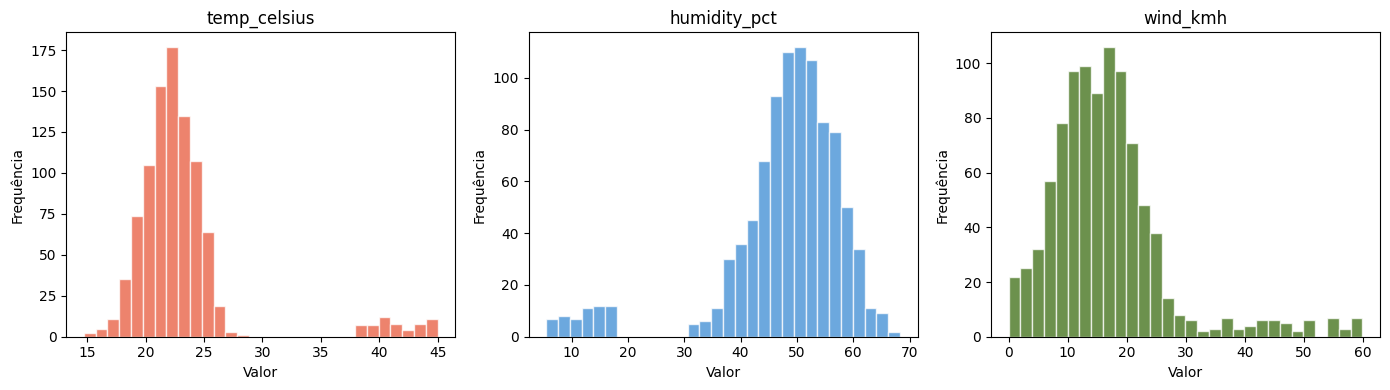

Histogramas guardados em work/data_quality_histograms.png


In [27]:
# ── Análise de outliers com pandas ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, color in zip(axes, ['temp_celsius', 'humidity_pct', 'wind_kmh'], ['#E8593C', '#3B8BD4', '#3B6D11']):
    ax.hist(df[col].dropna(), bins=30, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('/home/jovyan/work/data_quality_histograms.png', dpi=120)
plt.show()
print('Histogramas guardados em work/data_quality_histograms.png')

In [28]:
query = '''
from(bucket: "metrics")
  |> range(start: -1h)
  |> keys()
  |> distinct(column: "_field")
'''
result = influx.query_api().query(query)
for table in result:
    for record in table.records:
        print(record.values)

{'result': '_result', 'table': 0, '_start': datetime.datetime(2026, 5, 26, 22, 37, 35, 342497, tzinfo=tzlocal()), '_stop': datetime.datetime(2026, 5, 26, 23, 37, 35, 342497, tzinfo=tzlocal()), '_field': 'failed_expectations', '_measurement': 'data_quality', 'source': 'sensor_readings', '_value': 'failed_expectations'}
{'result': '_result', 'table': 1, '_start': datetime.datetime(2026, 5, 26, 22, 37, 35, 342497, tzinfo=tzlocal()), '_stop': datetime.datetime(2026, 5, 26, 23, 37, 35, 342497, tzinfo=tzlocal()), '_field': 'success_percent', '_measurement': 'data_quality', 'source': 'sensor_readings', '_value': 'success_percent'}
{'result': '_result', 'table': 2, '_start': datetime.datetime(2026, 5, 26, 22, 37, 35, 342497, tzinfo=tzlocal()), '_stop': datetime.datetime(2026, 5, 26, 23, 37, 35, 342497, tzinfo=tzlocal()), '_field': 'successful_expectations', '_measurement': 'data_quality', 'source': 'sensor_readings', '_value': 'successful_expectations'}
{'result': '_result', 'table': 3, '_star